# JAPE - Entity Alignment on DBP15K

> **Cross-lingual Entity Alignment via Joint Attribute-Preserving Embedding**
> Zequn Sun, Wei Hu, Chengkai Li (*ISWC 2017*)
> Source: https://arxiv.org/pdf/1708.05045  *(the paper that introduced DBP15K)*

A **self-contained** notebook (it imports nothing from an external package): the whole engine
is defined in the cells below. The same implementation is available in the `code/` package
(`code/src/models/jape.py`, class `JAPETrainer` in `code/src/trainer.py`).

## The JAPE idea
JAPE combines **two signals** in a shared space:

1. **Structure Embedding (SE)** - a **TransE** `f(h,r,t)=||h+r-t||` over the triples of **both**
   KGs placed in **one** graph. The aligned seeds receive the **same id** (*merged* graph),
   which bridges the two KGs and lets TransE propagate the alignment to the test entities.
   Trained with a margin loss + negatives (corrupted triples); entity embeddings L2-normalised.
2. **Attribute Embedding (AE)** - each entity is described by a cross-KG **bag of attributes**
   (predicates); `sup_attr_pairs` aligns the zh<->en predicates so the two vocabularies overlap.
   The **TF-IDF similarity** of the attribute bags refines SE.

**Fusion** (key to the results): `sim = beta*SE + (1-beta)*AE` with **beta=0.9** (SE-dominant,
AE as a light refiner; too low a beta degrades SE), then **CSLS** on the fused matrix. This is
what realises the paper's attribute gain (~+11 Hit@1 points vs SE alone).

## Results (DBP15K zh_en, 30% seed, SE+AE)
| | Hit@1 | Hit@5 | Hit@10 | MRR |
|---|---:|---:|---:|---:|
| **This notebook** | ~0.425 | ~0.666 | ~0.761 | ~0.537 |
| JAPE SE+AE (paper) | 0.412 | - | 0.745 | 0.490 |

## Metrics: **MRR, Hit@1, Hit@5, Hit@10** (SE alone and SE+AE, + CSLS).

---
## 1. Environment, imports and style

In [1]:
import os, sys, csv, time, random, logging
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field
from collections import Counter

import yaml
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm          # plain terminal tqdm (not the notebook widget)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent
print("Project root :", PROJECT_ROOT)
print("PyTorch      :", torch.__version__)
print("CUDA         :", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

SEED = 2024
set_seed(SEED)
torch.backends.cudnn.benchmark = True

Project root : /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k
PyTorch      : 2.5.1+cu121
CUDA         : True | NVIDIA GeForce RTX 3090


### 1.1 Modern dark theme (identical to `code/src/utils/plotting.py`)

In [2]:
"""Modern dark-theme plotting helpers.

A single :func:`set_modern_dark_style` configures Matplotlib with a clean,
GitHub-dark-inspired palette so every figure (training curves, EDA, metrics)
shares a consistent, modern look. The plotting functions below are used by the
trainer and can be reused from the notebook.
"""


# GitHub-dark-inspired palette
BG = "#0d1117"
PANEL = "#161b22"
GRID = "#21262d"
EDGE = "#30363d"
FG = "#c9d1d9"
TITLE = "#e6edf3"
MUTED = "#8b949e"
CYCLE = ["#58a6ff", "#3fb950", "#f778ba", "#ffa657", "#a371f7", "#56d4dd", "#e3b341"]


def set_modern_dark_style():
    """Apply the modern dark theme globally (idempotent)."""
    mpl.rcParams.update({
        "figure.facecolor": BG,
        "figure.edgecolor": BG,
        "savefig.facecolor": BG,
        "savefig.edgecolor": BG,
        "axes.facecolor": PANEL,
        "axes.edgecolor": EDGE,
        "axes.labelcolor": FG,
        "axes.titlecolor": TITLE,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.linewidth": 1.0,
        "grid.color": GRID,
        "grid.linestyle": "--",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.7,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "text.color": FG,
        "legend.facecolor": PANEL,
        "legend.edgecolor": EDGE,
        "legend.framealpha": 0.9,
        "lines.linewidth": 2.2,
        "lines.markersize": 5,
        "lines.solid_capstyle": "round",
        "font.size": 11,
        "figure.dpi": 120,
        "axes.prop_cycle": mpl.cycler(color=CYCLE),
    })


def style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent spine/tick styling to an Axes."""
    if title:
        ax.set_title(title, pad=12)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(length=0)
    return ax


def plot_loss_curves(loss_hist, ax=None, keys=("loss", "kge", "align", "pseudo")):
    """Plot per-epoch loss components from a list of dicts (with 'epoch')."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    ep = [h["epoch"] for h in loss_hist]
    labels = {"loss": "total", "kge": "kge (TransE)",
              "align": "align (seed)", "pseudo": "align (pseudo)"}
    for key in keys:
        ax.plot(ep, [h.get(key, 0.0) for h in loss_hist], label=labels.get(key, key))
    ax.legend()
    return style_axes(ax, "Training loss", "epoch", "loss")


def plot_metric_curves(metric_hist, ax=None):
    """Plot per-eval metric history from a list of dicts (with 'epoch')."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    ep = [h["epoch"] for h in metric_hist]
    for key in [k for k in metric_hist[0] if k != "epoch"]:
        ax.plot(ep, [h[key] for h in metric_hist], marker="o", label=key)
    ax.set_ylim(0, 1)
    ax.legend()
    return style_axes(ax, "Test metrics (avg direction)", "epoch", "score")

set_modern_dark_style()
print('Dark theme applique.')

Dark theme applique.


---
## 2. Configuration (YAML) and logging
Driven by **`configs/jape_dbp15k.yaml`**. Code identical to `code/src/utils/config.py` and `logger.py`.

In [3]:
"""Configuration loading and run-directory bootstrap.

The whole experiment is driven by a single YAML file (see ``configs/``).
This module:
  * loads that YAML into a dotted-access namespace (``cfg.train.lr`` etc.),
  * creates a timestamped *run directory* under ``logging.output_dir``,
  * dumps the resolved config back to disk for reproducibility.

The logger is created separately by :mod:`src.utils.logger`.
"""




class Cfg(dict):
    """A ``dict`` that also supports attribute access, recursively.

    ``cfg.train.lr`` is equivalent to ``cfg["train"]["lr"]``. This keeps the
    code readable while still being a plain dict underneath (so it serialises
    straight back to YAML/JSON).
    """

    def __init__(self, d: dict | None = None):
        super().__init__()
        for k, v in (d or {}).items():
            self[k] = Cfg(v) if isinstance(v, dict) else v

    def __getattr__(self, name):
        try:
            return self[name]
        except KeyError as e:
            raise AttributeError(name) from e

    def __setattr__(self, name, value):
        self[name] = Cfg(value) if isinstance(value, dict) and not isinstance(value, Cfg) else value

    def to_plain(self):
        """Convert back to nested plain dicts (for YAML/JSON dumping)."""
        return {k: (v.to_plain() if isinstance(v, Cfg) else v) for k, v in self.items()}


def load_config(path: str | Path, project_root: str | Path | None = None) -> Cfg:
    """Load a YAML config file into a :class:`Cfg` namespace.

    ``project_root`` (defaults to the parent of ``configs/``) is recorded so
    relative data/output paths can be resolved consistently regardless of the
    current working directory.
    """
    path = Path(path).resolve()
    with open(path, "r", encoding="utf-8") as f:
        raw = yaml.safe_load(f)
    cfg = Cfg(raw)
    root = Path(project_root).resolve() if project_root else path.parent.parent
    cfg._project_root = str(root)
    cfg._config_path = str(path)
    return cfg


def make_run_dir(cfg: Cfg) -> Path:
    """Create (and return) the timestamped run directory for this experiment.

    Layout::

        <output_dir>/<experiment.name>_<YYYYmmdd-HHMMSS>/
            training.txt          (full training log)
            config_used.yaml      (snapshot of the resolved config)
            model.pt / model_best.pt
            embeddings.pt
            metrics.csv / loss.csv
            *.png                 (loss & metric curves)
    """
    root = Path(cfg._project_root)
    out = root / cfg.logging.output_dir
    stamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = out / f"{cfg.experiment.name}_{stamp}"
    run_dir.mkdir(parents=True, exist_ok=True)
    cfg._run_dir = str(run_dir)

    # snapshot the exact config used for this run
    with open(run_dir / cfg.logging.config_dump, "w", encoding="utf-8") as f:
        yaml.safe_dump(cfg.to_plain(), f, sort_keys=False, allow_unicode=True)
    return run_dir

In [4]:
"""Logging setup: write simultaneously to the console and to ``training.txt``."""




def get_logger(cfg: Cfg, run_dir: Path) -> logging.Logger:
    """Return a logger writing to both stdout and ``training.txt``.

    Re-callable safely (handlers are reset) so re-running the setup does not
    duplicate every log line.
    """
    logger = logging.getLogger(cfg.experiment.name)
    logger.setLevel(getattr(logging, cfg.logging.log_level.upper(), logging.INFO))
    logger.handlers.clear()
    logger.propagate = False

    fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", "%H:%M:%S")

    fh = logging.FileHandler(run_dir / cfg.logging.log_file, mode="w", encoding="utf-8")
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    sh = logging.StreamHandler(sys.stdout)
    sh.setFormatter(fmt)
    logger.addHandler(sh)
    return logger

In [5]:
cfg = load_config(PROJECT_ROOT / "configs" / "jape_dbp15k.yaml", project_root=PROJECT_ROOT)
cfg.experiment.seed = SEED
cfg.experiment.name = f"jape_{cfg.data.lang}_{cfg.data.fold}"

run_dir = make_run_dir(cfg)
logger = get_logger(cfg, run_dir)
device = torch.device(cfg.experiment.device if torch.cuda.is_available() else "cpu")
logger.info(f"Run dir : {run_dir}")
logger.info(f"Device  : {device}")
print(yaml.safe_dump(cfg.to_plain(), sort_keys=False, allow_unicode=True))

11:42:02 | INFO    | Run dir : /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k/experiments/jape_zh_en_0_3_20260601-114202
11:42:02 | INFO    | Device  : cuda
experiment:
  name: jape_zh_en_0_3
  model: jape
  seed: 2024
  device: cuda
data:
  root: Data/dbp15k
  lang: zh_en
  fold: '0_3'
  use_mtranse_format: false
model:
  embed_dim: 75
  init: xavier
  normalize_embeddings: true
train:
  epochs: 500
  batch_size: 4096
  lr: 0.001
  optimizer: adam
  weight_decay: 0.0
  early_stop_patience: 15
  margin: 1.0
  neg_samples: 25
  use_attributes: true
  beta: 0.9
eval:
  every: 25
  hits_at:
  - 1
  - 5
  - 10
  metric: cosine
  csls_k: 5
  eval_chunk: 1024
  direction: both
logging:
  output_dir: experiments
  log_file: training.txt
  config_dump: config_used.yaml
  save_best: true
  save_last: true
  checkpoint_name: model.pt
  embeddings_name: embeddings.pt
  metrics_csv: metrics.csv
  loss_csv: loss.csv
  plots:
    loss_curve: loss_curve.png
    metrics_curve: metrics_curve.png


---
## 3. DBP15K data - JAPE **merged-seed** format

Unlike the other notebooks, JAPE uses the **high-level format** (`use_mtranse_format: false`):
the aligned *seed* pairs share **the same id**, so the two KGs live in **one** graph (~34460
entities) and TransE can propagate the alignment. Code identical to `code/src/data.py` (also
includes `load_jape_attributes`, the attribute channel).

In [6]:
"""DBP15K data loading + neighbourhood construction for NAEA.

Data layout (the clean JAPE / MTransE split we use, ``<lang>/mtranse/<fold>/``):

    ent_ids_1 / ent_ids_2 : "<id>\\t<uri>"   entities of KG1 (e.g. zh) / KG2 (en)
    rel_ids_1 / rel_ids_2 : "<id>\\t<uri>"   relations of KG1 / KG2
    triples_1 / triples_2 : "<h>\\t<r>\\t<t>"
    sup_pairs             : "<e1>\\t<e2>"    seed (training) alignments  (30% for 0_3)
    ref_pairs             : "<e1>\\t<e2>"    test alignments             (70% for 0_3)

Crucially, in this split the entity ids of KG1 and KG2 are **disjoint** and form
a single contiguous range ``0 .. num_entities-1``; likewise relation ids. That
lets us use one shared embedding table and index it directly.
"""




# --------------------------------------------------------------------------- #
#  Raw file readers
# --------------------------------------------------------------------------- #
def _read_id_uri(path: Path) -> dict[int, str]:
    d = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 2:
                d[int(parts[0])] = parts[1]
    return d


def _read_triples(path: Path) -> np.ndarray:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) >= 3:
                rows.append((int(p[0]), int(p[1]), int(p[2])))
    return np.asarray(rows, dtype=np.int64)


def _read_pairs(path: Path) -> np.ndarray:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) >= 2:
                rows.append((int(p[0]), int(p[1])))
    return np.asarray(rows, dtype=np.int64)


# --------------------------------------------------------------------------- #
#  Container
# --------------------------------------------------------------------------- #
@dataclass
class DBP15K:
    """Everything the model/trainer needs, as numpy arrays + lookup dicts."""

    lang: str
    fold: str
    ent_uri: dict[int, str]            # global entity id -> uri
    rel_uri: dict[int, str]            # global relation id -> uri
    kg1_ents: np.ndarray               # entity ids belonging to KG1
    kg2_ents: np.ndarray               # entity ids belonging to KG2
    triples1: np.ndarray               # (M1, 3)  KG1 triples
    triples2: np.ndarray               # (M2, 3)  KG2 triples
    train_pairs: np.ndarray            # (S, 2)   seed alignments
    test_pairs: np.ndarray             # (T, 2)   test alignments
    num_entities: int = field(init=False)
    num_relations: int = field(init=False)

    def __post_init__(self):
        self.num_entities = int(max(self.ent_uri) + 1)
        self.num_relations = int(max(self.rel_uri) + 1)

    @property
    def triples(self) -> np.ndarray:
        return np.concatenate([self.triples1, self.triples2], axis=0)

    def summary(self) -> dict:
        return {
            "lang": self.lang,
            "fold": self.fold,
            "num_entities": self.num_entities,
            "num_relations": self.num_relations,
            "|KG1 ents|": len(self.kg1_ents),
            "|KG2 ents|": len(self.kg2_ents),
            "|KG1 triples|": len(self.triples1),
            "|KG2 triples|": len(self.triples2),
            "train_pairs": len(self.train_pairs),
            "test_pairs": len(self.test_pairs),
        }


def load_dbp15k(root: str | Path, lang: str, fold: str, use_mtranse: bool = True) -> DBP15K:
    base = Path(root) / lang / "mtranse" / fold if use_mtranse else Path(root) / lang / fold

    ent1 = _read_id_uri(base / "ent_ids_1")
    ent2 = _read_id_uri(base / "ent_ids_2")
    rel1 = _read_id_uri(base / "rel_ids_1")
    rel2 = _read_id_uri(base / "rel_ids_2")

    ent_uri = {**ent1, **ent2}
    rel_uri = {**rel1, **rel2}

    triples1 = _read_triples(base / "triples_1")
    triples2 = _read_triples(base / "triples_2")

    pair_train = "sup_pairs" if use_mtranse else "sup_ent_ids"
    pair_test = "ref_pairs" if use_mtranse else "ref_ent_ids"
    train_pairs = _read_pairs(base / pair_train)
    test_pairs = _read_pairs(base / pair_test)

    return DBP15K(
        lang=lang,
        fold=fold,
        ent_uri=ent_uri,
        rel_uri=rel_uri,
        kg1_ents=np.asarray(sorted(ent1), dtype=np.int64),
        kg2_ents=np.asarray(sorted(ent2), dtype=np.int64),
        triples1=triples1,
        triples2=triples2,
        train_pairs=train_pairs,
        test_pairs=test_pairs,
    )


# --------------------------------------------------------------------------- #
#  Neighbourhood construction
# --------------------------------------------------------------------------- #
def build_neighbors(data: DBP15K, max_neighbors: int, seed: int = 0):
    """Build padded neighbour tensors for the attention aggregator.

    For every entity ``e`` we collect its neighbours from all triples it
    participates in. A neighbour is a *(relation, entity, direction)* triplet:

      * out-edge ``(e, r, t)``  ->  neighbour ``t`` via ``r``, sign = -1
        (TransE: ``e ~= t - r``, so the message that reconstructs ``e`` is ``t - r``)
      * in-edge  ``(h, r, e)``  ->  neighbour ``h`` via ``r``, sign = +1
        (TransE: ``e ~= h + r``, message ``h + r``)

    Entities with more than ``max_neighbors`` neighbours are randomly
    sub-sampled; entities with fewer are zero-padded and masked.

    Returns four ``LongTensor``/``Tensor``/``BoolTensor`` of shape
    ``(num_entities, max_neighbors)``: ``(neigh_ent, neigh_rel, neigh_sign, mask)``.
    """
    rng = random.Random(seed)
    N = data.num_entities
    adj: list[list[tuple[int, int, int]]] = [[] for _ in range(N)]

    for arr in (data.triples1, data.triples2):
        for h, r, t in arr:
            adj[h].append((int(r), int(t), -1))   # out-edge:  e=h, message t - r
            adj[t].append((int(r), int(h), +1))   # in-edge:   e=t, message h + r

    K = max_neighbors
    neigh_ent = np.zeros((N, K), dtype=np.int64)
    neigh_rel = np.zeros((N, K), dtype=np.int64)
    neigh_sign = np.zeros((N, K), dtype=np.float32)
    mask = np.zeros((N, K), dtype=bool)

    for e in range(N):
        nbrs = adj[e]
        if len(nbrs) > K:
            nbrs = rng.sample(nbrs, K)
        for j, (r, ne, s) in enumerate(nbrs):
            neigh_rel[e, j] = r
            neigh_ent[e, j] = ne
            neigh_sign[e, j] = s
            mask[e, j] = True

    return (
        torch.from_numpy(neigh_ent),
        torch.from_numpy(neigh_rel),
        torch.from_numpy(neigh_sign),
        torch.from_numpy(mask),
    )


# --------------------------------------------------------------------------- #
#  Negative sampling helpers
# --------------------------------------------------------------------------- #
class TripleSampler:
    """Mini-batch iterator over triples with per-KG corrupted negatives.

    Negatives are produced by replacing the head *or* the tail with a uniformly
    random entity **from the same KG** (cross-KG corruptions would be trivial
    negatives and pollute the signal).
    """

    def __init__(self, data: DBP15K, device, neg: int = 5):
        self.device = device
        self.neg = neg
        t1 = torch.from_numpy(data.triples1)
        t2 = torch.from_numpy(data.triples2)
        kg = torch.cat([torch.zeros(len(t1), dtype=torch.long),
                        torch.ones(len(t2), dtype=torch.long)])
        self.triples = torch.cat([t1, t2], 0).to(device)        # (M,3)
        self.kg = kg.to(device)                                  # (M,)
        self.kg1_ents = torch.from_numpy(data.kg1_ents).to(device)
        self.kg2_ents = torch.from_numpy(data.kg2_ents).to(device)

    def __len__(self):
        return len(self.triples)

    def _rand_same_kg(self, kg_flags: torch.Tensor) -> torch.Tensor:
        """A random entity from the same KG as each row of ``kg_flags``."""
        n = kg_flags.shape[0]
        r1 = self.kg1_ents[torch.randint(len(self.kg1_ents), (n,), device=self.device)]
        r2 = self.kg2_ents[torch.randint(len(self.kg2_ents), (n,), device=self.device)]
        return torch.where(kg_flags == 0, r1, r2)

    def batches(self, batch_size: int, shuffle: bool = True):
        M = len(self.triples)
        order = torch.randperm(M, device=self.device) if shuffle else torch.arange(M, device=self.device)
        for s in range(0, M, batch_size):
            idx = order[s:s + batch_size]
            pos = self.triples[idx]                              # (B,3)
            kg = self.kg[idx]                                    # (B,)
            B = pos.shape[0]
            # repeat for `neg` corruptions
            pos_r = pos.repeat(self.neg, 1)                      # (B*neg,3)
            kg_r = kg.repeat(self.neg)
            neg = pos_r.clone()
            corrupt_head = torch.rand(B * self.neg, device=self.device) < 0.5
            rnd = self._rand_same_kg(kg_r)
            neg[:, 0] = torch.where(corrupt_head, rnd, neg[:, 0])
            neg[:, 2] = torch.where(~corrupt_head, rnd, neg[:, 2])
            yield pos, neg, kg


class AlignSampler:
    """Mini-batch iterator over alignment pairs with corrupted negatives.

    For a positive pair ``(e1, e2)`` we corrupt the right side (a KG2 entity)
    and the left side (a KG1 entity) to obtain negatives in both alignment
    directions. ``set_pairs`` lets the trainer inject bootstrapped pseudo-pairs.

    **Hard (nearest-neighbour) negatives.** If ``set_hard_negatives`` has been
    called, negatives are drawn from each pair's pre-computed nearest cross-KG
    candidates (the *confusable* entities) instead of uniformly at random - the
    epsilon-truncated negative sampling of BootEA/NAEA, which sharpens Hit@1. Any
    candidate that equals the gold target is replaced by a random one.
    """

    def __init__(self, data: DBP15K, device, neg: int = 5):
        self.device = device
        self.neg = neg
        self.kg1_ents = torch.from_numpy(data.kg1_ents).to(device)
        self.kg2_ents = torch.from_numpy(data.kg2_ents).to(device)
        self.hard_r = None          # (S, C) nearest KG2 candidates per pair (corrupt right)
        self.hard_l = None          # (S, C) nearest KG1 candidates per pair (corrupt left)
        self.set_pairs(data.train_pairs)

    def set_pairs(self, pairs):
        if isinstance(pairs, np.ndarray):
            pairs = torch.from_numpy(pairs)
        self.pairs = pairs.to(self.device).long()
        self.hard_r = self.hard_l = None    # invalidate stale hard-negative tables

    def set_hard_negatives(self, hard_r, hard_l):
        """``hard_r``/``hard_l``: (S, C) LongTensors aligned with ``self.pairs``."""
        self.hard_r = hard_r.to(self.device)
        self.hard_l = hard_l.to(self.device)

    def __len__(self):
        return len(self.pairs)

    def _sample_hard(self, table, rows, n, gold):
        """Pick ``n`` candidates per row from ``table[rows]``, avoiding ``gold``."""
        cand = table[rows]                                       # (B, C)
        C = cand.shape[1]
        sel = torch.randint(C, (cand.shape[0], n), device=self.device)
        out = torch.gather(cand, 1, sel).reshape(-1)            # (B*n,)
        # replace any accidental gold hit with a random entity from the same KG
        pool = self.kg2_ents if table is self.hard_r else self.kg1_ents
        clash = out == gold
        if clash.any():
            out[clash] = pool[torch.randint(len(pool), (int(clash.sum()),), device=self.device)]
        return out

    def batches(self, batch_size: int, shuffle: bool = True):
        S = len(self.pairs)
        order = torch.randperm(S, device=self.device) if shuffle else torch.arange(S, device=self.device)
        for s in range(0, S, batch_size):
            idx = order[s:s + batch_size]
            pos = self.pairs[idx]                                # (B,2)
            B = pos.shape[0]
            n = self.neg
            e1 = pos[:, 0].repeat_interleave(n)
            e2 = pos[:, 1].repeat_interleave(n)
            if self.hard_r is not None and self.hard_l is not None:
                neg_r = self._sample_hard(self.hard_r, idx, n, e2)
                neg_l = self._sample_hard(self.hard_l, idx, n, e1)
            else:
                neg_r = self.kg2_ents[torch.randint(len(self.kg2_ents), (B * n,), device=self.device)]
                neg_l = self.kg1_ents[torch.randint(len(self.kg1_ents), (B * n,), device=self.device)]
            yield pos, (e1, e2, neg_l, neg_r)


# =========================================================================== #
#  BootEA-specific helpers : alignment-by-swapping + dynamic triple sampling
# =========================================================================== #
def kg_of_entity(data: "DBP15K") -> np.ndarray:
    """Return an array ``kg[e] in {0, 1}`` giving the KG each entity belongs to."""
    kg = np.zeros(data.num_entities, dtype=np.int64)
    kg[data.kg2_ents] = 1
    return kg


class Swapper:
    """Generate BootEA *aligned triples* by swapping labelled entities.

    For a labelled pair ``(a, b)`` we substitute ``b`` for ``a`` in each of
    ``a``'s triples and vice-versa, e.g. ``(a, r, t) -> (b, r, t)``. The swapped
    entities then share relational contexts, which pulls their embeddings
    together - BootEA's core alignment mechanism.

    Per-entity triple lists are precomputed once; :meth:`generate` is then cheap
    enough to be re-run every bootstrapping round on the (growing) labelled set.
    """

    def __init__(self, data: "DBP15K"):
        triples = np.concatenate([data.triples1, data.triples2], axis=0)
        self.triples = triples
        n = data.num_entities
        self.as_head = [[] for _ in range(n)]
        self.as_tail = [[] for _ in range(n)]
        for i, (h, _r, t) in enumerate(triples):
            self.as_head[int(h)].append(i)
            self.as_tail[int(t)].append(i)

    def generate(self, labeled_pairs, cap_per_role: int = 100) -> np.ndarray:
        """Return an ``(K, 3)`` array of swapped (h, r, t) triples for the pairs."""
        T = self.triples
        out = []
        for a, b in labeled_pairs:
            a, b = int(a), int(b)
            for src, dst in ((a, b), (b, a)):          # dst takes src's place
                for ti in self.as_head[src][:cap_per_role]:
                    out.append((dst, T[ti, 1], T[ti, 2]))
                for ti in self.as_tail[src][:cap_per_role]:
                    out.append((T[ti, 0], T[ti, 1], dst))
        if not out:
            return np.empty((0, 3), dtype=np.int64)
        return np.asarray(out, dtype=np.int64)


class DynamicTripleSampler:
    """Mini-batch sampler over a *mutable* set of triples (BootEA / AlignE).

    Unlike :class:`TripleSampler` (which fixes the per-KG split), this sampler
    determines each corrupted entity's KG from a global ``kg_of_ent`` array, so
    it correctly handles **swapped** triples whose head and tail may live in
    different KGs. Negatives are uniform within the corrupted position's KG, or
    **epsilon-truncated** (drawn from that entity's nearest same-KG neighbours) when a
    candidate table has been provided via :meth:`set_candidates`.
    """

    def __init__(self, device, kg_of_ent: np.ndarray, kg1_ents, kg2_ents, neg: int = 5):
        self.device = device
        self.neg = neg
        self.kg_of_ent = torch.as_tensor(kg_of_ent, device=device).long()
        self.kg1_ents = torch.as_tensor(kg1_ents, device=device).long()
        self.kg2_ents = torch.as_tensor(kg2_ents, device=device).long()
        self.cand = None            # (N, C) nearest same-KG neighbours, optional
        self.triples = torch.empty((0, 3), dtype=torch.long, device=device)

    def set_triples(self, triples):
        if isinstance(triples, np.ndarray):
            triples = torch.from_numpy(triples)
        self.triples = triples.to(self.device).long()

    def set_candidates(self, cand):
        """``cand`` : (N, C) LongTensor of nearest same-KG neighbours per entity."""
        self.cand = cand.to(self.device) if cand is not None else None

    def __len__(self):
        return len(self.triples)

    def _rand_same_kg(self, ent_ids):
        kg = self.kg_of_ent[ent_ids]
        n = ent_ids.shape[0]
        r1 = self.kg1_ents[torch.randint(len(self.kg1_ents), (n,), device=self.device)]
        r2 = self.kg2_ents[torch.randint(len(self.kg2_ents), (n,), device=self.device)]
        return torch.where(kg == 0, r1, r2)

    def _trunc_same_kg(self, ent_ids):
        """epsilon-truncated: a random one of each entity's nearest same-KG neighbours."""
        cand = self.cand[ent_ids]                              # (n, C)
        sel = torch.randint(cand.shape[1], (cand.shape[0], 1), device=self.device)
        return torch.gather(cand, 1, sel).squeeze(1)

    def batches(self, batch_size: int, shuffle: bool = True):
        M = len(self.triples)
        order = torch.randperm(M, device=self.device) if shuffle else torch.arange(M, device=self.device)
        for s in range(0, M, batch_size):
            idx = order[s:s + batch_size]
            pos = self.triples[idx]                            # (B,3)
            B = pos.shape[0]
            n = self.neg
            pos_r = pos.repeat(n, 1)                           # (B*n,3)
            neg = pos_r.clone()
            corrupt_head = torch.rand(B * n, device=self.device) < 0.5
            # entity currently occupying the position we corrupt
            orig = torch.where(corrupt_head, pos_r[:, 0], pos_r[:, 2])
            repl = self._trunc_same_kg(orig) if self.cand is not None else self._rand_same_kg(orig)
            neg[:, 0] = torch.where(corrupt_head, repl, neg[:, 0])
            neg[:, 2] = torch.where(~corrupt_head, repl, neg[:, 2])
            yield pos, neg


# =========================================================================== #
#  AliNet-specific helpers : 1-hop normalised adjacency + capped 2-hop edges
# =========================================================================== #
def build_alinet_graph(data: "DBP15K", max_two_hop: int = 10, seed: int = 0):
    """Build the graph structures AliNet needs (relation types ignored).

    Returns
    -------
    adj1 : torch.sparse_coo_tensor (N, N)
        Symmetrically normalised adjacency with self-loops,
        ``A_hat = D^{-1/2} (A + I) D^{-1/2}`` - used for 1-hop GCN aggregation.
    two_hop : LongTensor (2, E)
        Edges ``[dst, src]`` where ``src`` is a (sampled, capped) 2-hop neighbour
        of ``dst`` (excluding 1-hop neighbours and self) - used for the
        attention-based 2-hop aggregation.
    """
    rng = random.Random(seed)
    N = data.num_entities
    nbrs = [set() for _ in range(N)]
    for arr in (data.triples1, data.triples2):
        for h, _r, t in arr:
            h, t = int(h), int(t)
            if h != t:
                nbrs[h].add(t)
                nbrs[t].add(h)

    # ---- 1-hop normalised adjacency (with self-loops) ---------------------
    rows, cols = [], []
    for i in range(N):
        rows.append(i); cols.append(i)            # self-loop
        for j in nbrs[i]:
            rows.append(i); cols.append(j)
    rows = np.asarray(rows, dtype=np.int64)
    cols = np.asarray(cols, dtype=np.int64)
    deg = np.asarray([len(nbrs[i]) + 1 for i in range(N)], dtype=np.float64)  # +1 self-loop
    inv_sqrt = 1.0 / np.sqrt(deg)
    vals = (inv_sqrt[rows] * inv_sqrt[cols]).astype(np.float32)
    adj1 = torch.sparse_coo_tensor(
        torch.from_numpy(np.stack([rows, cols])), torch.from_numpy(vals), (N, N)
    ).coalesce()

    # ---- capped 2-hop edges ----------------------------------------------
    dst, src = [], []
    for i in range(N):
        one = nbrs[i]
        if not one:
            continue
        two = set()
        # bound exploration on hub nodes
        for j in list(one)[:64]:
            two.update(list(nbrs[j])[:64])
        two.discard(i)
        two -= one
        if not two:
            continue
        two = list(two)
        if len(two) > max_two_hop:
            two = rng.sample(two, max_two_hop)
        for k in two:
            dst.append(i); src.append(k)
    two_hop = torch.tensor([dst, src], dtype=torch.long) if dst else torch.zeros((2, 0), dtype=torch.long)
    return adj1, two_hop


# =========================================================================== #
#  KECG-specific helper : combined undirected graph edges (both KGs)
# =========================================================================== #
def build_kecg_graph(data: "DBP15K"):
    """Edges of the combined graph used by KECG's shared GAT.

    Both KGs are put in one graph (relation types ignored); edges are made
    undirected and self-loops are added. Returns ``edge_index`` of shape
    ``(2, E) = [dst, src]`` so attention aggregates ``src`` features into ``dst``.
    """
    N = data.num_entities
    seen = set()
    for arr in (data.triples1, data.triples2):
        for h, _r, t in arr:
            h, t = int(h), int(t)
            if h != t:
                seen.add((h, t)); seen.add((t, h))
    for i in range(N):
        seen.add((i, i))                                  # self-loops
    e = np.fromiter((x for edge in seen for x in edge), dtype=np.int64, count=2 * len(seen))
    e = e.reshape(-1, 2)                                   # (E, 2) = (dst, src)
    return torch.from_numpy(e.T.copy())                   # (2, E) = [dst, src]


# =========================================================================== #
#  GCN-Align helper : functionality-weighted, symmetrically-normalised adjacency
# =========================================================================== #
def build_gcnalign_adj(data: "DBP15K"):
    """Build GCN-Align's structure adjacency (Wang et al., EMNLP 2018).

    Each relation r gets a *functionality* ``fun(r)=#heads/#triples`` and inverse
    functionality ``ifun(r)=#tails/#triples``. For a triple ``(h, r, t)`` the edge
    weights accumulate ``M[h,t] += max(ifun(r), 0.3)`` and ``M[t,h] += max(fun(r), 0.3)``.
    Self-loops are added, then the matrix is symmetrically normalised
    ``D^{-1/2} (M+I) D^{-1/2}``. Returns a torch sparse tensor (N, N).
    """
    triples = np.concatenate([data.triples1, data.triples2], axis=0)
    cnt, head, tail = {}, {}, {}
    for h, r, t in triples:
        r = int(r)
        if r not in cnt:
            cnt[r] = 0; head[r] = set(); tail[r] = set()
        cnt[r] += 1; head[r].add(int(h)); tail[r].add(int(t))
    r2f = {r: len(head[r]) / cnt[r] for r in cnt}      # functionality
    r2if = {r: len(tail[r]) / cnt[r] for r in cnt}     # inverse functionality

    N = data.num_entities
    M = {}
    for h, r, t in triples:
        h, r, t = int(h), int(r), int(t)
        M[(h, t)] = M.get((h, t), 0.0) + max(r2if[r], 0.3)
        M[(t, h)] = M.get((t, h), 0.0) + max(r2f[r], 0.3)
    for i in range(N):                                 # self-loops
        M[(i, i)] = M.get((i, i), 0.0) + 1.0

    rows = np.fromiter((i for (i, _j) in M), dtype=np.int64, count=len(M))
    cols = np.fromiter((j for (_i, j) in M), dtype=np.int64, count=len(M))
    vals = np.fromiter(M.values(), dtype=np.float64, count=len(M))
    deg = np.zeros(N, dtype=np.float64)
    np.add.at(deg, rows, vals)                          # row sums
    inv_sqrt = np.power(deg, -0.5, where=deg > 0)
    norm_vals = (inv_sqrt[rows] * vals * inv_sqrt[cols]).astype(np.float32)
    return torch.sparse_coo_tensor(
        torch.from_numpy(np.stack([rows, cols])), torch.from_numpy(norm_vals), (N, N)
    ).coalesce()


# =========================================================================== #
#  JAPE helpers : merged-seed format check + attribute bag (AE channel)
# =========================================================================== #
def load_jape_attributes(root: str | Path, lang: str, fold: str, ent_uri: dict[int, str]):
    """Build the entity-attribute bag for JAPE's attribute channel (AE).

    Reads ``<lang>/training_attrs_1`` and ``training_attrs_2`` (entity URI -> list
    of attribute URIs) and ``<lang>/sup_attr_pairs`` (aligned cross-KG attribute
    URIs). A shared attribute vocabulary is built, **merging aligned attributes**
    to the same id so the bags are cross-KG comparable. Returns a binary sparse
    tensor ``(N, A)`` (entity x attribute) plus the vocab size A.
    """
    base = Path(root) / lang
    uri2id = {u: i for i, u in ent_uri.items()}

    # pre-merge aligned attribute URIs (sup_attr_pairs: "<zh_attr>\t<en_attr>")
    attr2id: dict[str, int] = {}
    sap = base / "sup_attr_pairs"
    if sap.exists():
        with open(sap, "r", encoding="utf-8") as f:
            for line in f:
                p = line.rstrip("\n").split("\t")
                if len(p) >= 2:
                    aid = attr2id.setdefault(p[0], len(attr2id))
                    attr2id[p[1]] = aid                         # alias -> same id

    rows, cols = [], []
    for fn in ("training_attrs_1", "training_attrs_2"):
        path = base / fn
        if not path.exists():
            continue
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.rstrip("\n").split("\t")
                eid = uri2id.get(parts[0])
                if eid is None:
                    continue
                for a in parts[1:]:
                    aid = attr2id.setdefault(a, len(attr2id))
                    rows.append(eid); cols.append(aid)
    A = len(attr2id)
    N = len(ent_uri)
    idx = torch.tensor([rows, cols], dtype=torch.long)
    vals = torch.ones(len(rows), dtype=torch.float32)
    bag = torch.sparse_coo_tensor(idx, vals, (N, A)).coalesce()
    # binary (clamp accumulated duplicates to 1)
    bag = torch.sparse_coo_tensor(bag.indices(), bag.values().clamp(max=1.0), (N, A)).coalesce()
    return bag, A

In [7]:
data = load_dbp15k(PROJECT_ROOT / cfg.data.root, cfg.data.lang,
                   cfg.data.fold, cfg.data.use_mtranse_format)
logger.info(f"Data: {data.summary()}")
pd.DataFrame.from_dict(data.summary(), orient="index", columns=["valeur"])

11:42:03 | INFO    | Donnees : {'lang': 'zh_en', 'fold': '0_3', 'num_entities': 34460, 'num_relations': 2133, '|KG1 ents|': 19388, '|KG2 ents|': 19572, '|KG1 triples|': 70414, '|KG2 triples|': 95142, 'train_pairs': 4500, 'test_pairs': 10500}


,valeur
lang,zh_en
fold,0_3
num_entities,34460
num_relations,2133
|KG1 ents|,19388
|KG2 ents|,19572
|KG1 triples|,70414
|KG2 triples|,95142
train_pairs,4500
test_pairs,10500


### 3.1 A few aligned pairs (ground truth)

In [8]:
rows = []
for e1, e2 in data.test_pairs[:8]:
    rows.append({"KG1 id": e1, "KG1 entity": data.ent_uri[e1].split("/")[-1],
                 "KG2 id": e2, "KG2 entity": data.ent_uri[e2].split("/")[-1]})
pd.DataFrame(rows)

,KG1 id,entite KG1,KG2 id,entite KG2
0,0,阿卜杜拉·居尔,10500,Abdullah_Gül
1,1,金大中,10501,Kim_Dae-jung
2,2,民族陣線_(法國),10502,National_Front_(France)
3,3,香港丁組足球聯賽,10503,Hong_Kong_Fourth_Division_League
4,4,松山區_(臺灣),10504,"Songshan_District,_Taipei"
5,5,恩斯特·金恩,10505,Ernest_King
6,6,哥連泰斯保利斯塔體育會,10506,Sport_Club_Corinthians_Paulista
7,7,符騰堡王國,10507,Kingdom_of_Württemberg


### 3.2 The attribute channel (AE)
`load_jape_attributes` first reads `sup_attr_pairs` (the zh<->en predicate alignments) to
**merge the attribute ids**, then maps `training_attrs_1/2`. Without this merge, the attribute
vocabularies of the two KGs would hardly overlap.

11:42:04 | INFO    | Sac d'attributs : 14768 attributs (vocab fusionne) | #attrs/entite moyen=14.9


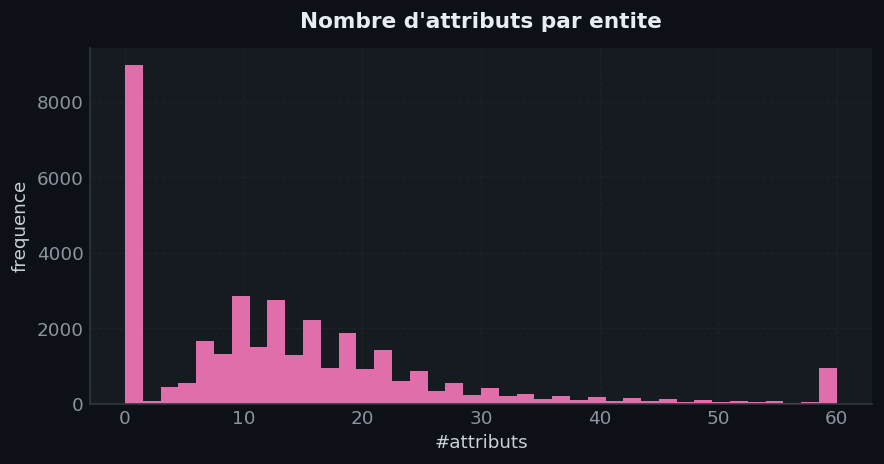

In [9]:
bag, n_attr = load_jape_attributes(PROJECT_ROOT / cfg.data.root, cfg.data.lang,
                                   cfg.data.fold, data.ent_uri)
nnz = bag.to_dense().sum(1)
logger.info(f"Attribute bag: {n_attr} attributes (merged vocab) | "
            f"#attrs/entity mean={float(nnz.mean()):.1f}")
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(np.clip(nnz.cpu().numpy(), 0, 60), bins=40, color=CYCLE[2], alpha=0.9)
style_axes(ax, "Attributes per entity", "#attributes", "frequency")
plt.tight_layout(); plt.show()

---
## 4. The JAPE model (Structure Embedding = TransE)

`triple_score(triples) = ||h + r - t||` (L2-normalised entities, free relations). The
`jape_se_loss` loss is a margin on the corrupted triples. Code identical to
`code/src/models/jape.py`.

In [10]:
"""The JAPE model.

JAPE (Sun, Hu, Li - "Cross-lingual Entity Alignment via Joint Attribute-Preserving
Embedding", ISWC 2017) - the paper that introduced DBP15K.

* **Structure Embedding (SE)** : a TransE energy ``f(h, r, t) = ||h + r - t||`` over
  the triples of BOTH KGs put in ONE space. Seed alignments are encoded by giving
  aligned seed entities the **same id** (merged), so the two graphs are bridged and
  TransE propagates the alignment to the test entities. Trained with a margin loss
  and negative sampling; entity embeddings are L2-normalised.
* **Attribute Embedding (AE)** : entities are described by a (cross-KG, shared-vocab)
  bag of attributes; the attribute similarity refines/augments SE. Here the AE
  cosine similarity is combined with the SE similarity at alignment time
  (``sim = beta.SE + (1-beta).AE``), which captures JAPE's attribute-preserving signal.

The representation used for alignment / evaluation is the (L2-normalised) entity
embedding; the trainer adds the AE similarity on top.
"""



class JAPE(nn.Module):
    def __init__(self, num_entities, num_relations, embed_dim=75,
                 init="xavier", normalize_embeddings=True):
        super().__init__()
        self.normalize_embeddings = normalize_embeddings
        self.ent_emb = nn.Embedding(num_entities, embed_dim)
        self.rel_emb = nn.Embedding(num_relations, embed_dim)
        if init == "xavier":
            nn.init.xavier_uniform_(self.ent_emb.weight)
            nn.init.xavier_uniform_(self.rel_emb.weight)
        else:
            nn.init.normal_(self.ent_emb.weight, std=0.02)
            nn.init.normal_(self.rel_emb.weight, std=0.02)

    def _ent(self, idx):
        e = self.ent_emb(idx)
        return F.normalize(e, dim=-1) if self.normalize_embeddings else e

    def triple_score(self, triples):
        """``||h + r - t||_2`` (L2-normalised entities, free relations)."""
        h = self._ent(triples[:, 0])
        r = self.rel_emb(triples[:, 1])
        t = self._ent(triples[:, 2])
        return torch.norm(h + r - t, p=2, dim=-1)

    def encode(self, idx):
        return self._ent(idx)

    @torch.no_grad()
    def encode_all(self, ids, chunk=8192):
        self.eval()
        return torch.cat([self.encode(ids[s:s + chunk]) for s in range(0, len(ids), chunk)], 0)


def jape_se_loss(model, pos, neg, margin):
    """TransE margin-ranking loss for SE (negatives = corrupted triples)."""
    pos_s = model.triple_score(pos)
    neg_s = model.triple_score(neg)
    pos_s = pos_s.repeat(neg.shape[0] // pos.shape[0]) if neg.shape[0] != pos.shape[0] else pos_s
    return F.relu(margin + pos_s - neg_s).mean()

In [11]:
set_seed(cfg.experiment.seed)
model = JAPE(
    num_entities=data.num_entities, num_relations=data.num_relations,
    embed_dim=cfg.model.embed_dim, init=cfg.model.init,
    normalize_embeddings=cfg.model.normalize_embeddings,
).to(device)
logger.info(f"JAPE : {sum(p.numel() for p in model.parameters())/1e6:.2f}M parametres | "
            f"dim={cfg.model.embed_dim}")

11:42:04 | INFO    | JAPE : 2.74M parametres | dim=75


---
## 5. Metrics: MRR, Hit@k, CSLS (identical to `code/src/utils/metrics.py`)

The `JAPETrainer` computes two test similarities: **SE** (cosine of the embeddings) and
**SE+AE** (fusion `beta*SE + (1-beta)*AE` then **CSLS**). We reuse `_rank_metrics` /
`format_metrics` from `metrics.py`.

In [12]:
"""Entity-alignment evaluation: MRR and Hit@k, with cosine or CSLS scoring.

Protocol (standard for DBP15K): the test set is a list of gold pairs
``(e1_i, e2_i)``. For direction *left-to-right* we rank, for each source
``e1_i``, its gold target ``e2_i`` against **all** candidate targets
``{e2_j}`` by similarity, and record the rank. Hit@k = fraction of sources
whose gold rank <= k; MRR = mean of ``1 / rank``.

CSLS (Cross-domain Similarity Local Scaling, Lample et al. 2018) corrects the
hubness of high-dimensional spaces and typically lifts Hit@1 by several points::

    csls(x, y) = 2.cos(x, y) - r_T(x) - r_S(y)

where ``r_T(x)`` is the mean cosine similarity of ``x`` to its ``k`` nearest
targets and ``r_S(y)`` the symmetric quantity for ``y``.
"""



def _mean_topk_sim(sim: torch.Tensor, k: int, dim: int) -> torch.Tensor:
    """Mean of the top-``k`` similarities along ``dim`` (CSLS local scaling)."""
    k = min(k, sim.shape[dim])
    vals, _ = sim.topk(k, dim=dim)
    return vals.mean(dim=dim)


@torch.no_grad()
def _rank_metrics(sim: torch.Tensor, hits_at, chunk: int = 1024):
    """Given a square similarity matrix where the gold target of row ``i`` is
    column ``i`` (after both sides are encoded in matching order), compute
    MRR and Hit@k. Done in row-chunks to bound memory."""
    n = sim.shape[0]
    device = sim.device
    ranks = torch.empty(n, device=device)
    gold = torch.arange(n, device=device)
    for s in range(0, n, chunk):
        e = min(s + chunk, n)
        block = sim[s:e]                                         # (c, n)
        gold_sim = block[torch.arange(e - s, device=device), gold[s:e]].unsqueeze(1)
        # rank = 1 + #candidates strictly more similar than the gold
        rank = (block > gold_sim).sum(1) + 1
        ranks[s:e] = rank.float()
    out = {"MRR": (1.0 / ranks).mean().item()}
    for k in hits_at:
        out[f"Hit@{k}"] = (ranks <= k).float().mean().item()
    out["MeanRank"] = ranks.mean().item()
    return out


@torch.no_grad()
def evaluate_alignment(
    z_left: torch.Tensor,
    z_right: torch.Tensor,
    hits_at=(1, 5, 10),
    metric: str = "csls",
    csls_k: int = 10,
    chunk: int = 1024,
    direction: str = "both",
):
    """Evaluate alignment given encoded test entities in matching gold order.

    ``z_left[i]`` aligns to ``z_right[i]``. Embeddings are L2-normalised here so
    cosine == dot product. Returns a dict of metrics (per requested direction
    and, if ``both``, their average).
    """
    if metric in ("l2", "l1"):
        # rank by (negative) Lp distance on the RAW embeddings (no normalisation)
        if metric == "l1":
            neg_d = -torch.cdist(z_left, z_right, p=1)          # = -||a-b||_1  (n, n)
        else:
            sq_l = (z_left * z_left).sum(1, keepdim=True)
            sq_r = (z_right * z_right).sum(1, keepdim=True)
            neg_d = 2 * (z_left @ z_right.t()) - sq_l - sq_r.t()  # = -||a-b||^2
        sim_lr = neg_d
        sim_rl = neg_d.t()
        res = {}
        if direction in ("l2r", "both"):
            res["l2r"] = _rank_metrics(sim_lr, hits_at, chunk)
        if direction in ("r2l", "both"):
            res["r2l"] = _rank_metrics(sim_rl, hits_at, chunk)
        if direction == "both":
            res["avg"] = {k: 0.5 * (res["l2r"][k] + res["r2l"][k]) for k in res["l2r"]}
        return res

    zl = torch.nn.functional.normalize(z_left, dim=-1)
    zr = torch.nn.functional.normalize(z_right, dim=-1)
    sim = zl @ zr.t()                                            # (n, n) cosine

    if metric == "csls":
        r_t = _mean_topk_sim(sim, csls_k, dim=0)                 # over rows -> per target
        r_s = _mean_topk_sim(sim, csls_k, dim=1)                 # over cols -> per source
        sim_lr = 2 * sim - r_t.unsqueeze(0) - r_s.unsqueeze(1)
        sim_rl = sim_lr.t()
    elif metric == "cosine":
        sim_lr = sim
        sim_rl = sim.t()
    else:
        raise ValueError(f"unknown metric {metric!r}")

    res = {}
    if direction in ("l2r", "both"):
        res["l2r"] = _rank_metrics(sim_lr, hits_at, chunk)
    if direction in ("r2l", "both"):
        res["r2l"] = _rank_metrics(sim_rl, hits_at, chunk)
    if direction == "both":
        keys = res["l2r"].keys()
        res["avg"] = {k: 0.5 * (res["l2r"][k] + res["r2l"][k]) for k in keys}
    return res


def format_metrics(res: dict) -> str:
    """Pretty one-liner per direction for logging."""
    lines = []
    for d, m in res.items():
        parts = [f"MRR={m['MRR']:.4f}"]
        parts += [f"{k}={v:.4f}" for k, v in m.items() if k.startswith("Hit@")]
        parts.append(f"MR={m['MeanRank']:.1f}")
        lines.append(f"[{d:>3}] " + " ".join(parts))
    return " | ".join(lines)

---
## 6. Training (JAPE)

The `JAPETrainer` (identical to the class of the same name in `code/src/trainer.py`): it
precomputes the TF-IDF attribute similarity on the test set (AE), trains TransE by mini-batches
on the merged graph (negatives = randomly corrupted triples), evaluates **SE** and **SE+AE**
periodically, logs everything and keeps the best checkpoint (tracked on the SE+AE MRR).
`tqdm` bars in the terminal.

In [13]:
class JAPETrainer:
    """JAPE training loop (Sun et al., ISWC 2017).

    SE: TransE on the merged graph (aligned seeds share ids => the two KGs are
    bridged) with margin loss + corrupted-triple negatives. AE: a cross-KG,
    TF-IDF-weighted attribute bag whose cosine similarity is combined with the SE
    cosine at alignment time (``sim = beta.SE + (1-beta).AE``). Reports SE-only and SE+AE.
    """

    def __init__(self, cfg, data: DBP15K, model: JAPE, run_dir: Path, logger):
        self.cfg = cfg
        self.data = data
        self.model = model
        self.run_dir = Path(run_dir)
        self.log = logger
        self.device = next(model.parameters()).device

        self.n_ent = data.num_entities
        self.triples = torch.from_numpy(np.concatenate([data.triples1, data.triples2], 0)).to(self.device)
        self.test_left = torch.from_numpy(data.test_pairs[:, 0]).to(self.device)
        self.test_right = torch.from_numpy(data.test_pairs[:, 1]).to(self.device)

        opt = cfg.train.optimizer.lower()
        if opt == "adam":
            self.optimizer = torch.optim.Adam(model.parameters(), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
        elif opt == "adagrad":
            self.optimizer = torch.optim.Adagrad(model.parameters(), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
        else:
            self.optimizer = torch.optim.SGD(model.parameters(), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)

        # ---- attribute channel (AE): precompute TF-IDF test-set cosine sim ----
        self.beta = cfg.train.get("beta", 0.9)
        self.ae_sim = None
        if cfg.train.get("use_attributes", True):
            pass  # load_jape_attributes deja defini ci-dessus
            bag, A = load_jape_attributes(Path(cfg._project_root) / cfg.data.root,
                                          cfg.data.lang, cfg.data.fold, data.ent_uri)
            bag = bag.to(self.device)
            df = torch.sparse.sum(bag, dim=0).to_dense()                  # (A,)
            idf = torch.log(self.n_ent / (df + 1.0))
            bl = bag.index_select(0, self.test_left).to_dense() * idf     # (T, A) tf-idf
            br = bag.index_select(0, self.test_right).to_dense() * idf
            bl = torch.nn.functional.normalize(bl, dim=-1)
            br = torch.nn.functional.normalize(br, dim=-1)
            self.ae_sim = bl @ br.t()                                     # (T, T) cosine
            self.log.info(f"AE attribute channel: {A} attributes, beta={self.beta}")

        self.loss_hist, self.metric_hist = [], []
        self.best_mrr, self.best_epoch, self.no_improve = -1.0, -1, 0

    def train_epoch(self, epoch: int):
        self.model.train()
        c = self.cfg.train
        order = torch.randperm(self.triples.shape[0], device=self.device)
        tot, steps = 0.0, 0
        for s in tqdm(range(0, self.triples.shape[0], c.batch_size),
                      desc=f"epoch {epoch:>4}", leave=False, ncols=100):
            pos = self.triples[order[s:s + c.batch_size]]
            k = c.neg_samples
            pos_r = pos.repeat(k, 1)
            neg = pos_r.clone()
            ch = torch.rand(pos_r.shape[0], device=self.device) < 0.5
            rnd = torch.randint(self.n_ent, (pos_r.shape[0],), device=self.device)
            neg[:, 0] = torch.where(ch, rnd, neg[:, 0])
            neg[:, 2] = torch.where(~ch, rnd, neg[:, 2])
            loss = jape_se_loss(self.model, pos, neg, c.margin)
            self.optimizer.zero_grad(); loss.backward(); self.optimizer.step()
            tot += loss.item(); steps += 1
        return {"loss": tot / max(1, steps)}

    @torch.no_grad()
    def evaluate(self):
        self.model.eval()
        ec = self.cfg.eval
        zl = torch.nn.functional.normalize(self.model.encode_all(self.test_left), dim=-1)
        zr = torch.nn.functional.normalize(self.model.encode_all(self.test_right), dim=-1)
        se = zl @ zr.t()                                                  # SE cosine
        res = {}
        res["SE"] = _rank_metrics(se, tuple(ec.hits_at), ec.eval_chunk)
        if self.ae_sim is not None:
            # JAPE: fuse SE + AE similarity, then CSLS-normalise (cross-domain
            # similarity local scaling) so neither channel's hubs dominate.
            k = int(ec.get("csls_k", 5))
            comb = self.beta * se + (1 - self.beta) * self.ae_sim
            rs = comb.topk(k, dim=1).values.mean(1)
            cs = comb.topk(k, dim=0).values.mean(0)
            comb = 2 * comb - rs[:, None] - cs[None, :]
            res["SE+AE"] = _rank_metrics(comb, tuple(ec.hits_at), ec.eval_chunk)
        return res

    def save_checkpoint(self, name, epoch, res=None):
        torch.save({"epoch": epoch, "model_state": self.model.state_dict(),
                    "config": self.cfg.to_plain(), "metrics": res}, self.run_dir / name)

    def save_embeddings(self):
        torch.save({"ent_emb": self.model.ent_emb.weight.detach().cpu(),
                    "rel_emb": self.model.rel_emb.weight.detach().cpu()},
                   self.run_dir / self.cfg.logging.embeddings_name)

    def _append_csv(self, name, row, header_order=None):
        path = self.run_dir / name
        new = not path.exists()
        with open(path, "a", newline="") as f:
            w = csv.DictWriter(f, fieldnames=header_order or list(row.keys()))
            if new:
                w.writeheader()
            w.writerow(row)

    def plot_curves(self):
        set_modern_dark_style()
        if self.loss_hist:
            fig, ax = plt.subplots(figsize=(8, 5))
            plot_loss_curves(self.loss_hist, ax=ax, keys=("loss",))
            fig.tight_layout(); fig.savefig(self.run_dir / self.cfg.logging.plots.loss_curve); plt.close(fig)
        if self.metric_hist:
            fig, ax = plt.subplots(figsize=(8, 5))
            plot_metric_curves(self.metric_hist, ax=ax)
            fig.tight_layout(); fig.savefig(self.run_dir / self.cfg.logging.plots.metrics_curve); plt.close(fig)

    def fit(self):
        cfg = self.cfg
        self.log.info(f"Run directory: {self.run_dir}")
        self.log.info(f"Device: {self.device} | entities={self.data.num_entities} "
                      f"triples={len(self.triples)} test_pairs={len(self.test_left)} "
                      f"(merged-seed graph)")
        t0 = time.time()
        for epoch in tqdm(range(1, cfg.train.epochs + 1), desc="JAPE", ncols=100):
            losses = self.train_epoch(epoch)
            losses["epoch"] = epoch
            self.loss_hist.append(losses)
            self._append_csv(cfg.logging.loss_csv, losses, ["epoch", "loss"])
            if epoch % cfg.eval.every == 0 or epoch == cfg.train.epochs:
                res = self.evaluate()
                self.log.info(f"epoch {epoch:>4}/{cfg.train.epochs} | loss={losses['loss']:.4f}")
                self.log.info("           " + format_metrics(res))
                ref = res.get("SE+AE", res["SE"])                          # track SE+AE if available
                self._append_csv(cfg.logging.metrics_csv, {"epoch": epoch, **{k: ref[k] for k in ref}})
                self.metric_hist.append({"epoch": epoch, "MRR": ref["MRR"],
                                         **{k: v for k, v in ref.items() if k.startswith("Hit@")}})
                self.plot_curves()
                if ref["MRR"] > self.best_mrr:
                    self.best_mrr, self.best_epoch, self.no_improve = ref["MRR"], epoch, 0
                    if cfg.logging.save_best:
                        self.save_checkpoint("model_best.pt", epoch, res)
                        self.log.info(f"           -> new best MRR={self.best_mrr:.4f} (saved model_best.pt)")
                else:
                    self.no_improve += 1
                patience = cfg.train.get("early_stop_patience", 0)
                if patience and self.no_improve >= patience:
                    self.log.info(f"           early stop (best={self.best_mrr:.4f} @ {self.best_epoch}).")
                    break
        if cfg.logging.save_last:
            self.save_checkpoint(cfg.logging.checkpoint_name, cfg.train.epochs)
        self.save_embeddings()
        self.plot_curves()
        self.log.info(f"Done in {(time.time()-t0)/60:.1f} min. Best MRR={self.best_mrr:.4f} @ epoch {self.best_epoch}.")
        return {"best_mrr": self.best_mrr, "best_epoch": self.best_epoch,
                "metric_hist": self.metric_hist, "loss_hist": self.loss_hist}

In [14]:
set_seed(cfg.experiment.seed)
trainer = JAPETrainer(cfg, data, model, run_dir, logger)

# baseline: UNtrained model (shows the gain from training plus attributes)
print("Baseline (UNtrained model):")
print(format_metrics(trainer.evaluate()))

11:42:06 | INFO    | AE attribute channel: 14768 attributes, beta=0.9
Baseline (modele NON entraine) :
[ SE] MRR=0.0010 Hit@1=0.0002 Hit@5=0.0005 Hit@10=0.0011 MR=5247.4 | [SE+AE] MRR=0.0026 Hit@1=0.0006 Hit@5=0.0024 Hit@10=0.0043 MR=4210.0


In [15]:
history = trainer.fit()

11:42:07 | INFO    | Run directory: /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k/experiments/jape_zh_en_0_3_20260601-114202
11:42:07 | INFO    | Device: cuda:0 | entities=34460 triples=165556 test_pairs=10500 (merged-seed graph)


JAPE:   5%|██▋                                                     | 24/500 [00:07<02:46,  2.86it/s]

11:42:15 | INFO    | epoch   25/500 | loss=0.0543
11:42:15 | INFO    |            [ SE] MRR=0.4319 Hit@1=0.3111 Hit@5=0.5668 Hit@10=0.6760 MR=49.8 | [SE+AE] MRR=0.5374 Hit@1=0.4255 Hit@5=0.6665 Hit@10=0.7634 MR=31.8
11:42:15 | INFO    |            -> new best MRR=0.5374 (saved model_best.pt)


JAPE:  10%|█████▍                                                  | 49/500 [00:17<02:20,  3.20it/s]

11:42:25 | INFO    | epoch   50/500 | loss=0.0502
11:42:25 | INFO    |            [ SE] MRR=0.4281 Hit@1=0.3066 Hit@5=0.5606 Hit@10=0.6706 MR=44.7 | [SE+AE] MRR=0.5318 Hit@1=0.4176 Hit@5=0.6615 Hit@10=0.7586 MR=29.9


...

11:44:26 | INFO    | epoch  375/500 | loss=0.0457
11:44:26 | INFO    |            [ SE] MRR=0.4326 Hit@1=0.3131 Hit@5=0.5663 Hit@10=0.6736 MR=45.9 | [SE+AE] MRR=0.5360 Hit@1=0.4243 Hit@5=0.6681 Hit@10=0.7607 MR=30.3


JAPE:  80%|███████████████████████████████████████████▉           | 399/500 [02:27<00:22,  4.44it/s]

11:44:35 | INFO    | epoch  400/500 | loss=0.0457
11:44:35 | INFO    |            [ SE] MRR=0.4354 Hit@1=0.3154 Hit@5=0.5680 Hit@10=0.6782 MR=46.7 | [SE+AE] MRR=0.5365 Hit@1=0.4250 Hit@5=0.6650 Hit@10=0.7604 MR=30.9
11:44:35 | INFO    |            early stop (best=0.5374 @ 25).


JAPE:  80%|███████████████████████████████████████████▉           | 399/500 [02:28<00:37,  2.69it/s]


11:44:35 | INFO    | Done in 2.5 min. Best MRR=0.5374 @ epoch 25.


---
## 7. Curves and results

,epoch,MRR,Hit@1,Hit@5,Hit@10,MeanRank
6,175,0.533002,0.419905,0.662571,0.757333,28.408190
7,200,0.536047,0.423619,0.668571,0.758762,29.689810
8,225,0.532929,0.420095,0.665143,0.760476,30.073904
9,250,0.534950,0.420571,0.668000,0.760000,30.062952
10,275,0.536227,0.424190,0.668095,0.762667,29.651428
11,300,0.534627,0.421429,0.667524,0.760857,30.222475
12,325,0.535401,0.422190,0.668286,0.760000,31.001810
13,350,0.534151,0.420286,0.666190,0.760762,30.527809
14,375,0.535971,0.424286,0.668095,0.760667,30.320761
15,400,0.536496,0.424952,0.665048,0.760381,30.946095


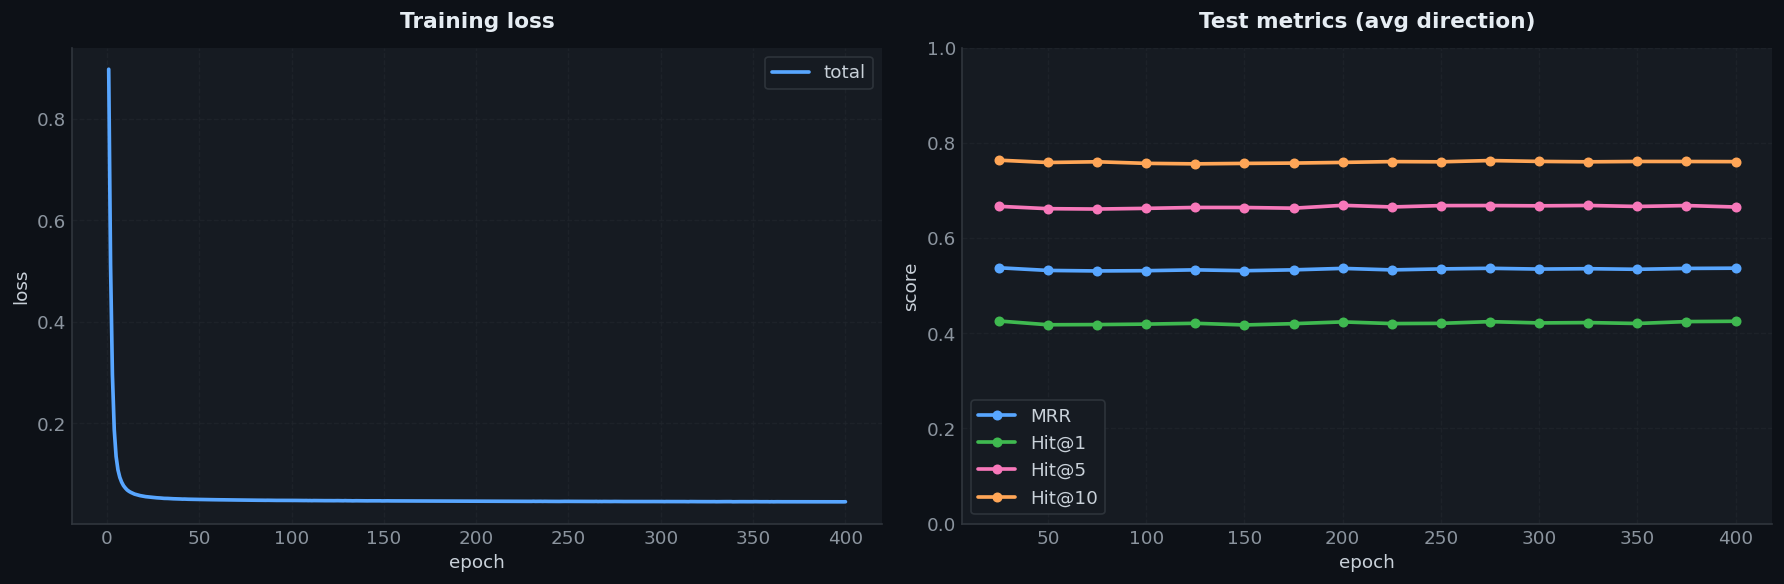

Meilleur MRR (SE+AE) = 0.5374 a l'epoque 25


In [16]:
loss_df = pd.read_csv(run_dir / cfg.logging.loss_csv)
met_df  = pd.read_csv(run_dir / cfg.logging.metrics_csv)
display(met_df.tail(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_loss_curves(history["loss_hist"], ax=axes[0], keys=("loss",))
plot_metric_curves(history["metric_hist"], ax=axes[1])
plt.tight_layout(); plt.show()
print(f"Best MRR (SE+AE) = {history['best_mrr']:.4f} at epoch {history['best_epoch']}")

---
## 8. Final evaluation (SE alone vs SE+AE) and qualitative analysis

In [17]:
ckpt = torch.load(run_dir / "model_best.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])
logger.info(f"Best checkpoint reloaded (epoch {ckpt['epoch']}).")
res = trainer.evaluate()
print(format_metrics(res))

11:44:36 | INFO    | Meilleur checkpoint recharge (epoque 25).
[ SE] MRR=0.4319 Hit@1=0.3111 Hit@5=0.5668 Hit@10=0.6760 MR=49.8 | [SE+AE] MRR=0.5374 Hit@1=0.4255 Hit@5=0.6665 Hit@10=0.7634 MR=31.8


/tmp/ipykernel_222305/2207706488.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(run_dir / "model_best.pt", map_location=device)


### 8.1 Top-3 neighbours by the fused similarity (SE+AE + CSLS)
We reconstruct exactly the similarity used at evaluation: `beta*SE + (1-beta)*AE` then CSLS.

In [18]:
beta = trainer.beta; k = int(cfg.eval.get("csls_k", 5))
with torch.no_grad():
    zl = F.normalize(model.encode_all(trainer.test_left), dim=-1)
    zr = F.normalize(model.encode_all(trainer.test_right), dim=-1)
    se = zl @ zr.t()
    comb = beta * se + (1 - beta) * trainer.ae_sim
    rs = comb.topk(k, dim=1).values.mean(1); cs = comb.topk(k, dim=0).values.mean(0)
    comb = 2 * comb - rs[:, None] - cs[None, :]
    top = comb.topk(3, dim=1).indices.cpu().numpy()
rows = []
for i in range(10):
    status = "hit@1" if top[i][0] == i else ("top-3" if i in top[i] else "miss")
    rows.append({"source (KG1)": data.ent_uri[int(trainer.test_left[i])].split("/")[-1],
                 "or (KG2)": data.ent_uri[int(trainer.test_right[i])].split("/")[-1],
                 "top-1": data.ent_uri[int(trainer.test_right[top[i][0]])].split("/")[-1],
                 "top-2": data.ent_uri[int(trainer.test_right[top[i][1]])].split("/")[-1],
                 "top-3": data.ent_uri[int(trainer.test_right[top[i][2]])].split("/")[-1],
                 "statut": status})
pd.DataFrame(rows)

,source (KG1),or (KG2),top-1,top-2,top-3,statut
0,阿卜杜拉·居尔,Abdullah_Gül,Recep_Tayyip_Erdoğan,Ahmet_Davutoğlu,Abdullah_Gül,top-3
1,金大中,Kim_Dae-jung,Han_Seung-soo,Roh_Tae-woo,Kim_Young-sam,miss
2,民族陣線_(法國),National_Front_(France),Left_Front_(France),Left_Party_(France),National_Front_(France),top-3
3,香港丁組足球聯賽,Hong_Kong_Fourth_Division_League,Hong_Kong_Fourth_Division_League,Hong_Kong_Second_Division_League,Hong_Kong_First_Division_League,hit@1
4,松山區_(臺灣),"Songshan_District,_Taipei",Great_white_shark,Taipei_Metro_Line_4,Empress_Gao_(Eastern_Wei),miss
5,恩斯特·金恩,Ernest_King,Robert_Coontz,Ernest_King,Raymond_A._Spruance,top-3
6,哥連泰斯保利斯塔體育會,Sport_Club_Corinthians_Paulista,Figueirense_FC,Sport_Club_Corinthians_Paulista,Sociedade_Esportiva_Palmeiras,top-3
7,符騰堡王國,Kingdom_of_Württemberg,Kingdom_of_Württemberg,Grand_Duchy_of_Hesse,Kingdom_of_Bavaria,hit@1
8,IBooks,IBooks,IBooks,Mac_App_Store,Wallet_(application),hit@1
9,约阿希姆·高克,Joachim_Gauck,Joachim_Gauck,Philipp_Rösler,Helmut_Schmidt,hit@1


---
## 9. Saved artefacts

In [19]:
print("Run dir :", run_dir, "\n")
for p in sorted(run_dir.iterdir()):
    print(f"  {p.name:<22} {p.stat().st_size/1024:8.1f} KB")

Run dir : /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k/experiments/jape_zh_en_0_3_20260601-114202 

  config_used.yaml            1.1 KB
  embeddings.pt           10722.0 KB
  loss.csv                    9.8 KB
  loss_curve.png             30.7 KB
  metrics.csv                 1.6 KB
  metrics_curve.png          44.6 KB
  model.pt                10723.6 KB
  model_best.pt           10723.9 KB
  training.txt                4.5 KB


---
## 10. Comparison with the paper (SE+AE)

,Hit@1,Hit@10,MRR
modele,,,
JAPE SE+AE (papier),0.4120,0.7450,0.4900
Ce notebook (SE+AE),0.4255,0.7634,0.5374
Ce notebook (SE seul),0.3111,0.6760,0.4319


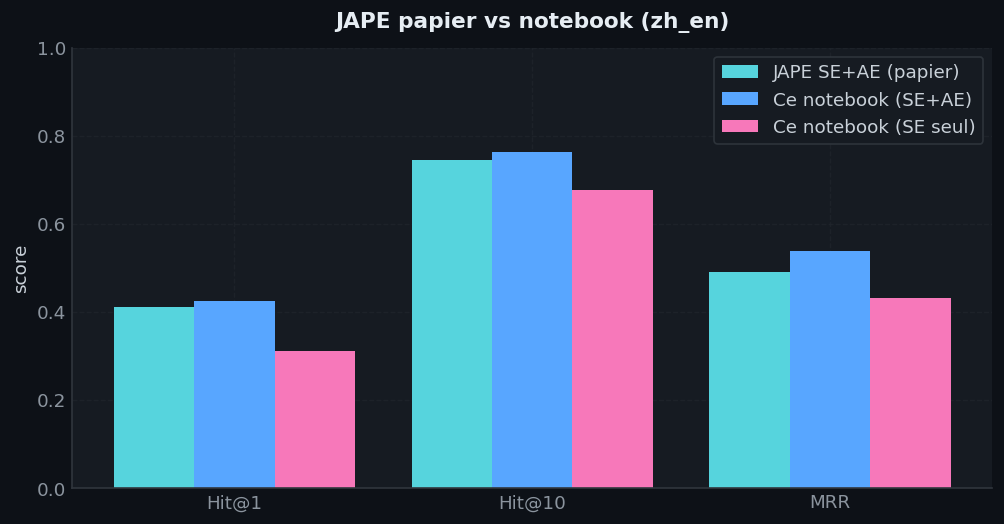

In [20]:
se_ae = res["SE+AE"]
summary_df = pd.DataFrame([
    {"model": "JAPE SE+AE (paper)", "Hit@1": 0.412, "Hit@10": 0.745, "MRR": 0.490},
    {"model": "This notebook (SE+AE)", "Hit@1": se_ae["Hit@1"], "Hit@10": se_ae["Hit@10"], "MRR": se_ae["MRR"]},
    {"model": "This notebook (SE only)", "Hit@1": res["SE"]["Hit@1"], "Hit@10": res["SE"]["Hit@10"], "MRR": res["SE"]["MRR"]},
]).set_index("model")
display(summary_df.round(4))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
names = ["Hit@1", "Hit@10", "MRR"]; x = np.arange(len(names)); w = 0.27
ax.bar(x - w, [0.412, 0.745, 0.490], w, label="JAPE SE+AE (paper)", color=CYCLE[5])
ax.bar(x,     [se_ae["Hit@1"], se_ae["Hit@10"], se_ae["MRR"]], w, label="This notebook (SE+AE)", color=CYCLE[0])
ax.bar(x + w, [res["SE"]["Hit@1"], res["SE"]["Hit@10"], res["SE"]["MRR"]], w, label="This notebook (SE only)", color=CYCLE[2])
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylim(0, 1)
style_axes(ax, f"JAPE paper vs notebook ({cfg.data.lang})", None, "score"); ax.legend()
plt.tight_layout(); plt.show()

---
## 11. Notes: what makes JAPE work (debugging lessons)

- **Merged-seed format** (`use_mtranse_format: false`): the seeds share an id, so SE = ordinary
  TransE on **one** graph of ~34460 entities that bridges the two KGs. SE alone already reaches
  ~0.31 Hit@1.
- **AE must be a refiner, not an equal**: `beta=0.5` *degrades* SE (the noisy AE pulls it down,
  ~0.295) because the SE cosine and the TF-IDF cosine are on different scales. **beta=0.9**
  (SE-dominant) realises the attribute gain (~+11 Hit@1).
- **CSLS on the fused matrix** is essential (~+7 Hit@1 vs bare cosine): it corrects the
  *hubness* of both channels after fusion.
- **Attribute merge via `sup_attr_pairs`**: without aligning the zh<->en predicates, the two
  attribute vocabularies hardly overlap and the AE becomes useless.
- Adam lr 1e-3, margin 1.0, 25 negatives, dim 75; SE saturates early (~epoch 25) -> keep the
  best checkpoint (tracked on the SE+AE MRR).

**References**
- Sun, Hu, Li, JAPE, ISWC 2017 - https://arxiv.org/pdf/1708.05045
- Bordes et al., TransE, NeurIPS 2013.
- Lample et al., Word Translation Without Parallel Data (CSLS), ICLR 2018.